# Day 2 – Linear Regression & Logistic Regression



---
#  Linear Regression 
---

## What is Regression?

In Day 1 we learned there are two types of Supervised Learning:
- **Classification** – predict a *category* (Yes/No, Spam/Not Spam)
- **Regression** – predict a *number* (Price, Revenue, Temperature)

**Linear Regression** is the simplest regression algorithm. It tries to draw a **straight line** through your data points so that the line is as close to all the points as possible.

**Real-life analogy:**
Imagine you are selling lemonade. You notice that on hotter days you sell more cups. If you plot temperature vs cups sold on a graph, you'll see the points roughly form a line going upward. Linear Regression finds the **best-fit line** through those points, so you can predict how many cups you'll sell tomorrow if you know the temperature.

## The Math Behind It 

The equation of a straight line is:

**y = mx + c**

Where:
- **y** = the value we want to predict (target) — e.g., Revenue
- **x** = the input feature — e.g., Quantity
- **m** = slope (how much y changes when x increases by 1)
- **c** = intercept (the value of y when x = 0)


## Assumptions of Linear Regression

Linear Regression works well **only when** certain assumptions are true. Think of these as "rules" that the data should follow:

| # | Assumption | Simple Explanation | Example |
|---|---|---|---|
| 1 | **Linearity** | The relationship between X and y should be roughly a straight line | If you plot Price vs Revenue, it should look like a line, not a curve |
| 2 | **No Multicollinearity** | Input features should not be highly correlated with each other | Price and Revenue_Per_Unit shouldn't both be used if they move together |
| 3 | **Homoscedasticity** | The spread of errors should be roughly the same everywhere | Predictions shouldn't be way off for expensive items but perfect for cheap ones |
| 4 | **Normal Residuals** | The errors (actual - predicted) should follow a bell curve | Most errors should be small, with very few large errors |
| 5 | **Independence** | Each data point should be independent of others | One transaction shouldn't influence another |

**Don't worry!** You don't need to memorize these. Just know they exist. In practice, we check them after building the model.

## Visualizing a Regression Line

Before we build a real model, let's **see** what a regression line actually looks like.

Remember the lemonade example? Let's plot Temperature vs Cups Sold and draw the best-fit line through the points. This is exactly what Linear Regression does — it finds the line that is closest to all the data points.

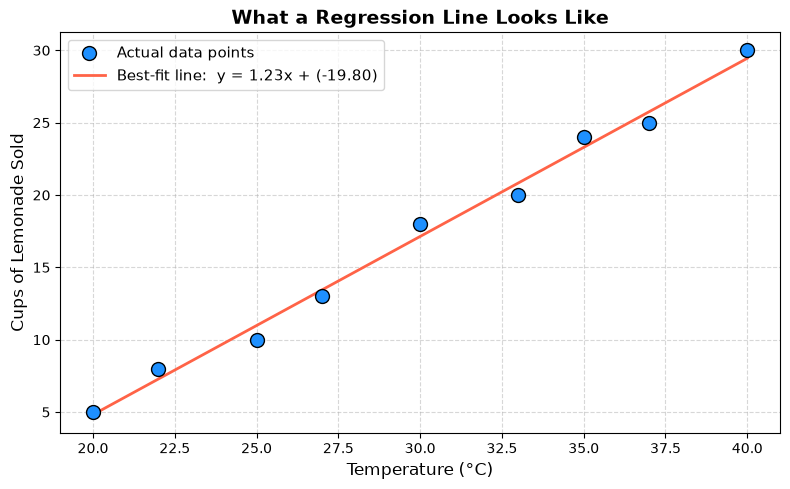

Slope  (m) = 1.23  → For every 1°C increase, we sell ~1.2 more cups
Intercept (c) = -19.80  → At 0°C we would (theoretically) sell -19.8 cups


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Simple made-up data: Temperature (°C) vs icecream Sold
temperature = np.array([20, 22, 25, 27, 30, 33, 35, 37, 40])
cups_sold   = np.array([ 5,  8, 10, 13, 18, 20, 24, 25, 30])

# Fit a straight line: y = m*x + c
m, c = np.polyfit(temperature, cups_sold, 1)
best_fit_line = m * temperature + c

# --- Plot ---
plt.figure(figsize=(8, 5))
plt.scatter(temperature, cups_sold, color='dodgerblue', s=100,
            edgecolors='black', zorder=3, label='Actual data points')
plt.plot(temperature, best_fit_line, color='tomato', linewidth=2,
         label=f'Best-fit line:  y = {m:.2f}x + ({c:.2f})')

plt.title('What a Regression Line Looks Like', fontsize=14, fontweight='bold')
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Cups of Lemonade Sold', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f'Slope  (m) = {m:.2f}  → For every 1°C increase, we sell ~{m:.1f} more cups')
print(f'Intercept (c) = {c:.2f}  → At 0°C we would (theoretically) sell {c:.1f} cups')

## Let's Build Our First Linear Regression Model!

**Goal:** Predict `Revenue` using `Price` and `Quantity`

Steps:
1. Load data
2. Select features (X) and target (y)
3. Train-Test split
4. Train the model
5. Make predictions
6. Evaluate the model

In [8]:
# Step 1: Load data
import pandas as pd
import numpy as np

df = pd.read_excel('sales_data.xlsx')
print('Shape:', df.shape)
df.head()

Shape: (85, 13)


,Transaction_ID,Date,Product,Category,Price,Quantity,Revenue,Day,DayOfWeek,WeekNumber,Revenue_Per_Unit,Revenue_Tier,Is_High_Value
0,TXN-1001,2026-01-07,Headphones,Accessories,150,2,300,7,Wednesday,2,150,Low,No
1,TXN-1002,2026-01-20,Smartphone,Electronics,600,4,2400,20,Tuesday,4,600,High,Yes
2,TXN-1003,2026-01-29,Smartphone,Electronics,600,3,1800,29,Thursday,5,600,Medium,Yes
3,TXN-1004,2026-01-15,Headphones,Accessories,150,1,150,15,Thursday,3,150,Low,No
4,TXN-1005,2026-01-11,Headphones,Accessories,150,4,600,11,Sunday,2,150,Medium,No


In [9]:
# Step 2: Select features and target
# we want to predict Revenue (a number) → this is a REGRESSION problem

X = df[['Price', 'Quantity']]   # features (inputs)
y = df['Revenue']               # target (what we predict)

print('Features shape:', X.shape)
print('Target shape:', y.shape)
print()
print('First 5 rows of features:')
print(X.head())
print()
print('First 5 values of target:')
print(y.head())

Features shape: (85, 2)
Target shape: (85,)

First 5 rows of features:
   Price  Quantity
0    150         2
1    600         4
2    600         3
3    150         1
4    150         4

First 5 values of target:
0     300
1    2400
2    1800
3     150
4     600
Name: Revenue, dtype: int64


In [10]:
# Step 3: Train-Test Split (from Day 1)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set:', X_train.shape[0], 'rows')
print('Testing set:', X_test.shape[0], 'rows')

Training set: 68 rows
Testing set: 17 rows


In [11]:
# Step 4: Train the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)   # model learns the best line from training data

# let's see what the model learned
print('Coefficients (weights):', model.coef_)
print('Intercept:', model.intercept_)
print()
print('This means:')
print(f'Revenue = ({model.coef_[0]:.2f} × Price) + ({model.coef_[1]:.2f} × Quantity) + ({model.intercept_:.2f})')

Coefficients (weights): [  2.59566912 508.37419071]
Intercept: -1217.5529574454717

This means:
Revenue = (2.60 × Price) + (508.37 × Quantity) + (-1217.55)


In [12]:
# Step 5: Make predictions on test data
y_pred = model.predict(X_test)

# let's compare actual vs predicted for first 10 rows
comparison = pd.DataFrame({
    'Actual Revenue': y_test.values,
    'Predicted Revenue': y_pred.round(2),
    'Difference': (y_test.values - y_pred).round(2)
})
print('Actual vs Predicted (first 10):')
print(comparison.head(10))

Actual vs Predicted (first 10):
   Actual Revenue  Predicted Revenue  Difference
0            1000            1843.45     -843.45
1             300             188.55      111.45
2             600            1205.29     -605.29
3            1200            1345.84     -145.84
4             150            -319.83      469.83
5            3000            2903.24       96.76
6            3000            2903.24       96.76
7            4000            3411.61      588.39
8             600            1205.29     -605.29
9             450             696.92     -246.92


In [13]:
# let's also predict for a brand new transaction
# what would be the revenue for Price=500, Quantity=3?

new_data = pd.DataFrame({'Price': [500], 'Quantity': [3]})
predicted_revenue = model.predict(new_data)
print(f'Predicted Revenue for Price=500, Quantity=3: ₹{predicted_revenue[0]:.2f}')

Predicted Revenue for Price=500, Quantity=3: ₹1605.40


## Regression Metrics – How Good Is Our Model?

We need a way to measure how well our model is performing. There are 3 common metrics:

### 1. Mean Absolute Error (MAE)
- **What:** Average of |actual - predicted| for all data points
- **Simple:** "On average, our prediction is off by ₹___ "
- **Lower is better**

### 2. Mean Squared Error (MSE)
- **What:** Average of (actual - predicted)² for all data points
- **Simple:** Same as MAE but it penalizes big errors more heavily (because of squaring)
- **Lower is better**

### 3. R² Score (R-Squared)
- **What:** How much of the variation in y is explained by our model
- **Simple:** "Our model explains ___% of the pattern in the data"
- **Range:** 0 to 1 (1 = perfect model, 0 = model is useless)
- **Higher is better**

| Metric | Formula Idea | Good Value |
|---|---|---|
| MAE | avg of \|errors\| | Close to 0 |
| MSE | avg of errors² | Close to 0 |
| R² | 1 - (errors / total variation) | Close to 1 |

In [14]:
# Step 6: Evaluate the model using metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)   # root mean squared error (easier to interpret than MSE)
r2 = r2_score(y_test, y_pred)

print('=== Model Performance ===')
print(f'MAE  (Mean Absolute Error):  {mae:.2f}')
print(f'  → On average, our prediction is off by ₹{mae:.2f}')
print()
print(f'MSE  (Mean Squared Error):   {mse:.2f}')
print(f'RMSE (Root MSE):             {rmse:.2f}')
print(f'  → Typical prediction error is around ₹{rmse:.2f}')
print()
print(f'R²   (R-Squared Score):      {r2:.4f}')
print(f'  → Our model explains {r2*100:.1f}% of the variation in Revenue')
mae_percentage=( rmse/y_test.mean()) *100
print(mae_percentage)

=== Model Performance ===
MAE  (Mean Absolute Error):  364.50
  → On average, our prediction is off by ₹364.50

MSE  (Mean Squared Error):   197831.97
RMSE (Root MSE):             444.78
  → Typical prediction error is around ₹444.78

R²   (R-Squared Score):      0.8373
  → Our model explains 83.7% of the variation in Revenue
41.775204526437186


## Quick Check: Assumptions

Let's quickly check two assumptions to show how it's done in practice.

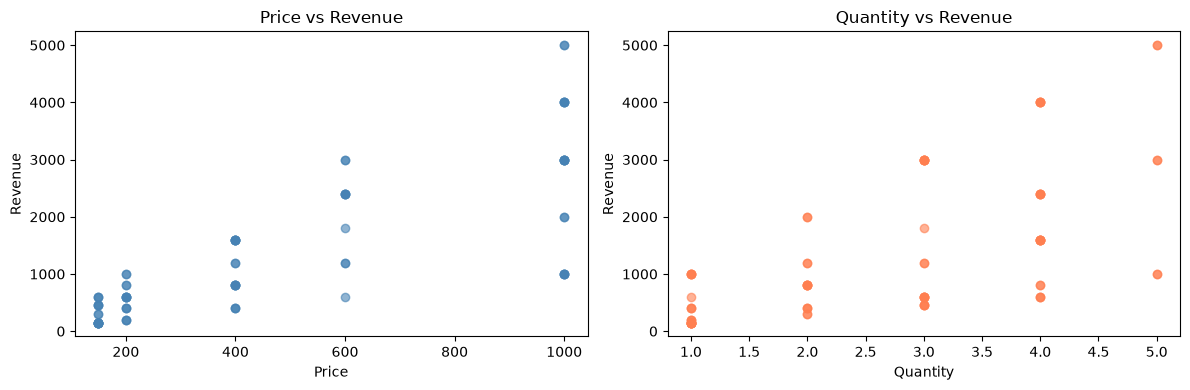

If the points show a roughly upward trend → linear relationship exists ✓


In [15]:
# Check 1: Linearity – is there a linear relationship between features and target?
# a simple scatter plot can tell us

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(df['Price'], df['Revenue'], color='steelblue', alpha=0.6)
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Revenue')
axes[0].set_title('Price vs Revenue')

axes[1].scatter(df['Quantity'], df['Revenue'], color='coral', alpha=0.6)
axes[1].set_xlabel('Quantity')
axes[1].set_ylabel('Revenue')
axes[1].set_title('Quantity vs Revenue')

plt.tight_layout()
plt.show()

print('If the points show a roughly upward trend → linear relationship exists ✓')

---
# Part 2 – Logistic Regression 
---

## What is Classification?

We already saw this briefly in Day 1. **Classification** is when we predict a **category/label**, not a number.

| Regression (predict a number) | Classification (predict a category) |
|---|---|
| "What will the Revenue be?" → ₹1500 | "Is this High Value?" → Yes / No |
| "What is the house price?" → ₹50 lakh | "Is this email Spam?" → Spam / Not Spam |
| "What will the temperature be?" → 35°C | "What disease does the patient have?" → Flu / COVID / Cold |

**Logistic Regression** is one of the simplest and most popular classification algorithms.


Yes! The name is confusing. It is called "regression" because internally it calculates a number (probability), but the final output is a category. Don't let the name fool you!

## The Sigmoid Function – Heart of Logistic Regression

Linear Regression gives us any number: -100, 0, 500, 99999...

But for classification we need a **probability** (a number between 0 and 1):
- Close to 1 → model is confident it is **Yes** (positive class)
- Close to 0 → model is confident it is **No** (negative class)
- Around 0.5 → model is **unsure**

The **Sigmoid Function** (also called Logistic Function) squeezes any number into the range 0 to 1:

**σ(z) = 1 / (1 + e⁻ᶻ)**

Where:
- z = the linear equation output (y=w₁x₁ + w₂x₂ + b)
- e = Euler's number (≈ 2.718)

**How it works:**
1. First, Logistic Regression calculates z = w₁×Price + w₂×Quantity + b (just like Linear Regression)
2. Then, it passes z through the Sigmoid function to get a probability (0 to 1)
3. If probability ≥ 0.5 → predict **Yes**, otherwise predict **No**

## Building a Logistic Regression Model

**Goal:** Predict `Is_High_Value` (Yes/No) using `Price` and `Quantity`

The steps are almost the same as Linear Regression!

In [16]:
# Step 1: Prepare the data
import pandas as pd
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel('sales_data.xlsx')

X = df[['Price', 'Quantity']]   # features
y = df['Is_High_Value']         # target (Yes/No)

# encode Yes/No to 1/0 (models need numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [17]:
# Step 2: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print('Training set:', X_train.shape[0], 'rows')
print('Testing set:', X_test.shape[0], 'rows')

Training set: 68 rows
Testing set: 17 rows


In [ ]:
# Step 3: Feature Scaling (important for Logistic Regression)
from sklearn.preprocessing import StandardScaler
# y=mx+c
# y=m1x1+m2x2+m3x3.......+c
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
# Step 4: Train Logistic Regression model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)

print('Model trained!')
print('Coefficients:', log_model.coef_)
print('Intercept:', log_model.intercept_)

Model trained!
Coefficients: [[2.65135642 1.36833642]]
Intercept: [1.772908]


In [32]:
# Step 5: Make predictions
y_pred = log_model.predict(X_test_scaled)

# we can also see the probabilities
y_prob = log_model.predict_proba(X_test_scaled)
# print(y_prob)
# show first 10 predictions with probabilities
results = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_pred),
    'Prob(No)': y_prob[:, 0].round(3),
    'Prob(Yes)': y_prob[:, 1].round(3)
})
print('Predictions with probabilities (first 10):')
print(results.sample(10))
print()
print('Note: The model picks the class with higher probability')

Predictions with probabilities (first 10):
   Actual Predicted  Prob(No)  Prob(Yes)
7     Yes       Yes     0.001      0.999
12     No        No     0.690      0.310
9      No        No     0.690      0.310
15     No        No     0.806      0.194
13    Yes       Yes     0.016      0.984
16     No        No     0.947      0.053
11     No       Yes     0.305      0.695
10     No        No     0.596      0.404
5     Yes       Yes     0.002      0.998
14     No        No     0.596      0.404

Note: The model picks the class with higher probability


## Confusion Matrix – Understanding Model Mistakes

A **Confusion Matrix** is a table that shows how many predictions were correct and how many were wrong.

For a binary classification (Yes/No) problem:

|  | **Predicted: No** | **Predicted: Yes** |
|---|---|---|
| **Actual: No** | True Negative (TN) ✅ | False Positive (FP) ❌ |
| **Actual: Yes** | False Negative (FN) ❌ | True Positive (TP) ✅ |

- **True Positive (TP):** Model said Yes, and it was actually Yes ✅
- **True Negative (TN):** Model said No, and it was actually No ✅
- **False Positive (FP):** Model said Yes, but it was actually No ❌ (False Alarm)
- **False Negative (FN):** Model said No, but it was actually Yes ❌ (Missed it)

**Simple analogy:**
Think of a fire alarm:
- TP: Alarm rings, and there IS a fire (correct!)
- TN: Alarm doesn't ring, and there is NO fire (correct!)
- FP: Alarm rings, but there is NO fire (false alarm – annoying but not dangerous)
- FN: Alarm doesn't ring, but there IS a fire (dangerous – we missed it!)

In [ ]:
# let's create the confusion matrix for our model
               #   predicted no     predicted yes  
    #  actual no:       TN               FP
    #  actual yes:      FN               TP
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:')
print(cm)
print()

# # extract values
# tn, fp, fn, tp = cm.ravel()
# print(f'True Negatives  (TN): {tn}  → correctly predicted No')
# print(f'False Positives (FP): {fp}  → wrongly predicted Yes (was actually No)')
# print(f'False Negatives (FN): {fn}  → wrongly predicted No (was actually Yes)')
# print(f'True Positives  (TP): {tp}  → correctly predicted Yes')

Confusion Matrix:
[[8 3]
 [0 6]]

True Negatives  (TN): 8  → correctly predicted No
False Positives (FP): 3  → wrongly predicted Yes (was actually No)
False Negatives (FN): 0  → wrongly predicted No (was actually Yes)
True Positives  (TP): 6  → correctly predicted Yes


<Figure size 600x500 with 0 Axes>

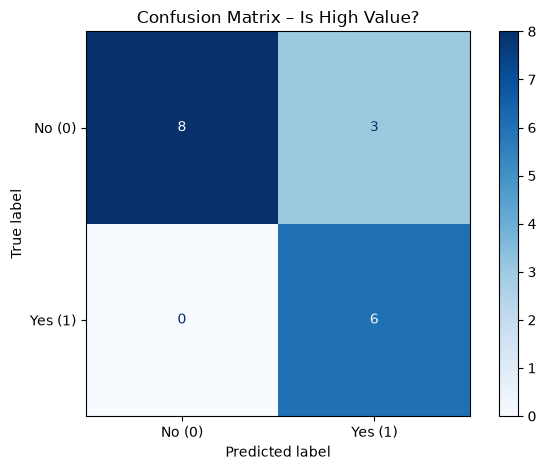

In [34]:
# visualize the confusion matrix
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Yes (1)'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix – Is High Value?')
plt.tight_layout()
plt.show()


## Precision, Recall, and F1-Score

Accuracy alone is not always enough. Consider this scenario:

You have 100 transactions: 95 are Not High Value, only 5 are High Value.
A lazy model that **always predicts "No"** will be 95% accurate! But it's useless because it missed all the High Value ones.

That's why we need **Precision, Recall, and F1-Score**.

---

### Precision – "Of all the times I said Yes, how many were actually Yes?"

**Precision = TP / (TP + FP)**

- High Precision = when the model says "Yes", it's usually right
- Think of it as: **how trustworthy is a "Yes" prediction?**
- Important when **false alarms are costly** (e.g., sending a patient to surgery)

---

### Recall – "Of all the actual Yes cases, how many did I catch?"

**Recall = TP / (TP + FN)**

- High Recall = the model catches most of the actual positive cases
- Think of it as: **how good is the model at finding all the Yes cases?**
- Important when **missing a positive case is dangerous** (e.g., missing a disease, missing fraud)

---

### F1-Score – "The balance between Precision and Recall"

**F1 = 2 × (Precision × Recall) / (Precision + Recall)**

- The harmonic mean of Precision and Recall
- Use when you want a **single number** that balances both
- Range: 0 to 1 (higher is better)

---

| Metric | Question it answers | Formula |
|---|---|---|
| **Accuracy** | How many total predictions were correct? | (TP + TN) / Total |
| **Precision** | When I predicted Yes, was I right? | TP / (TP + FP) |
| **Recall** | Did I catch all the actual Yes cases? | TP / (TP + FN) |
| **F1-Score** | Balance of Precision and Recall | 2 × P × R / (P + R) |

In [35]:
# let's calculate these metrics for our model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('=== Logistic Regression Performance ===')
print(f'Accuracy:  {accuracy:.2f}  → {accuracy*100:.0f}% predictions were correct overall')
print(f'Precision: {precision:.2f}  → When model said Yes, it was right {precision*100:.0f}% of the time')
print(f'Recall:    {recall:.2f}  → Model caught {recall*100:.0f}% of actual High Value transactions')
print(f'F1-Score:  {f1:.2f}  → Balance between Precision and Recall')

=== Logistic Regression Performance ===
Accuracy:  0.82  → 82% predictions were correct overall
Precision: 0.67  → When model said Yes, it was right 67% of the time
Recall:    1.00  → Model caught 100% of actual High Value transactions
F1-Score:  0.80  → Balance between Precision and Recall


In [ ]:
# sklearn also provides a nice summary called classification_report
from sklearn.metrics import classification_report

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['No (Not High Value)', 'Yes (High Value)']))
# wa= (1.00*11)+(0.67*6)/total sample size 

=== Classification Report ===
                     precision    recall  f1-score   support

No (Not High Value)       1.00      0.73      0.84        11
   Yes (High Value)       0.67      1.00      0.80         6

           accuracy                           0.82        17
          macro avg       0.83      0.86      0.82        17
       weighted avg       0.88      0.82      0.83        17



## When to Use Precision vs Recall?

| Scenario | Which metric matters more? | Why? |
|---|---|---|
| Email Spam Filter | **Precision** | You don't want important emails going to spam (false alarm is bad) |
| Disease Detection | **Recall** | You don't want to miss a sick patient (missing a positive is dangerous) |
| Fraud Detection | **Recall** | You don't want to miss fraud (missing fraud is costly) |
| Product Recommendation | **Precision** | You want recommended products to actually be relevant |
| Balanced scenario | **F1-Score** | When both precision and recall are equally important |

---
# Quick Summary
---

## Linear Regression
- Predicts a **number** (continuous value)
- Equation: y = w₁x₁ + w₂x₂ + b
- Metrics: **MAE** (average error), **MSE** (penalizes big errors), **R²** (how well model fits)
- Has assumptions: linearity, no multicollinearity, etc.

## Logistic Regression
- Predicts a **category** (classification)
- Uses the **Sigmoid function** to convert numbers into probabilities (0 to 1)
- If probability ≥ 0.5 → Yes, else → No

## Evaluation Metrics for Classification
- **Confusion Matrix** → shows TP, TN, FP, FN
- **Precision** → when I said Yes, was I right?
- **Recall** → did I catch all the actual Yes cases?
- **F1-Score** → balance of Precision and Recall

## Key Difference

| Feature | Linear Regression | Logistic Regression |
|---|---|---|
| Task | Regression (predict number) | Classification (predict category) |
| Output | Any number | Probability (0 to 1) |
| Metrics | MAE, MSE, R² | Accuracy, Precision, Recall, F1 |
| Example | Predict Revenue | Predict Is_High_Value |

---
## Practice Exercise

Try the following tasks on your own using the `sales_data.xlsx` dataset:

1. **Linear Regression** – Predict `Revenue` using `Price`, `Quantity`, and `Day`. Print the R² score on test data.
2. **Metrics** – Calculate MAE and RMSE for the model above. Which one is higher? Why?
3. **Logistic Regression** – Predict `Is_High_Value` using `Price`, `Quantity`, and `Revenue`. Print the accuracy.
4. **Confusion Matrix** – Plot the confusion matrix for the Logistic Regression model. How many False Negatives does it have?
5. **Classification Report** – Print the classification report. Which class has better recall – Yes or No?

In [ ]:
# ---------- PRACTICE ----------
# Complete each task below. Uncomment and fill in the blanks (___)

import pandas as pd
import numpy as np
df = pd.read_excel('DataSet_used\\sales_data.xlsx')

# --- Task 1: Linear Regression with 3 features ---
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
X = df[['Price', 'Quantity', ___]]
y = df['Revenue']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(___, ___)
y_pred = model.predict(___)
print('R² Score:', r2_score(___, ___).round(4))

# --- Task 2: MAE and RMSE ---
from sklearn.metrics import mean_absolute_error, mean_squared_error
mae = mean_absolute_error(___, ___)
rmse = np.sqrt(mean_squared_error(___, ___))
print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

# --- Task 3: Logistic Regression with 3 features ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
X = df[['Price', 'Quantity', ___]]
y = LabelEncoder().fit_transform(df['Is_High_Value'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
log_model = LogisticRegression()
log_model.fit(___, ___)
y_pred = log_model.predict(___)
print('Accuracy:', accuracy_score(___, ___))

# --- Task 4: Confusion Matrix ---
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(___, ___)
print('Confusion Matrix:', cm)
tn, fp, fn, tp = cm.ravel()
print(f'False Negatives: {fn}')

# --- Task 5: Classification Report ---
from sklearn.metrics import classification_report
print(classification_report(___, ___, target_names=['No', 'Yes']))